# 📰 Fake News Classifier — Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Optional but nice
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load the Data

In [3]:
df = pd.read_csv('WELFake_Dataset.csv').drop(columns=['Unnamed: 0'])

# Label decode for readability
df['label_name'] = df['label'].map({0: 'Fake', 1: 'Real'})

print(f'Shape: {df.shape}')
df.head()

Shape: (72134, 4)


,title,text,label,label_name
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,Real
1,NaN,Did they post their votes for Hillary already?,1,Real
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,Real
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,Fake
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,Real


## 2. Basic Info & Missing Values

In [4]:
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print('--- Duplicates ---')
print(f'Duplicate rows: {df.duplicated().sum()}')

--- Data Types ---
title         object
text          object
label          int64
label_name    object
dtype: object

--- Missing Values ---
title         558
text           39
label           0
label_name      0
dtype: int64

--- Duplicates ---
Duplicate rows: 8456


In [5]:
# Drop nulls and duplicates
df = df.dropna(subset=['title', 'text', 'label'])
df = df.drop_duplicates()
print(f'Clean shape: {df.shape}')

Clean shape: (63121, 4)


## 3. Class Distribution

label_name
Fake    34791
Real    28330
Name: count, dtype: int64

Class balance: 55.1% Fake / 44.9% Real


/var/folders/dg/hdz0102s321cbt41brs_8r040000gn/T/ipykernel_26149/4126445376.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'\nClass balance: {counts[0]/len(df)*100:.1f}% Fake / {counts[1]/len(df)*100:.1f}% Real')


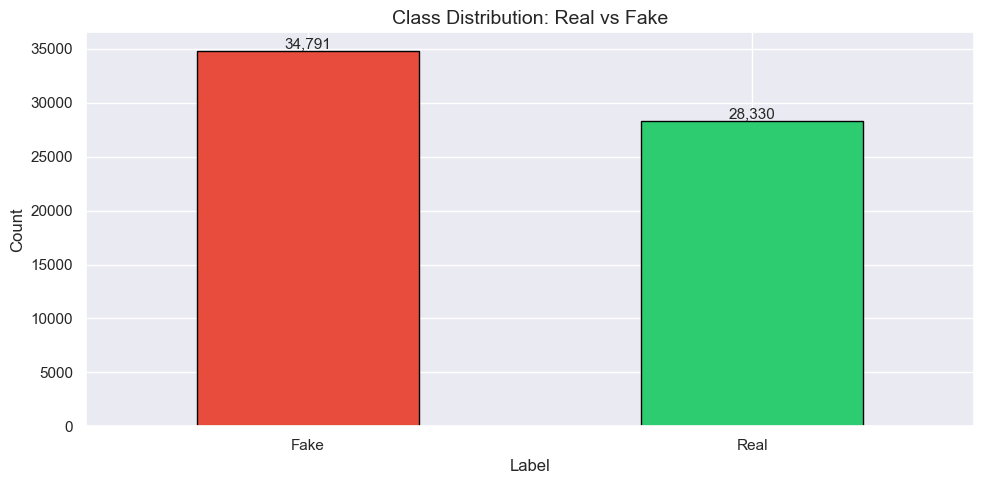

In [6]:
counts = df['label_name'].value_counts()
print(counts)
print(f'\nClass balance: {counts[0]/len(df)*100:.1f}% Fake / {counts[1]/len(df)*100:.1f}% Real')

ax = counts.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
ax.set_title('Class Distribution: Real vs Fake', fontsize=14)
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_xticklabels(counts.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height() + 200),
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Text Length Analysis

In [7]:
df['title_len'] = df['title'].astype(str).apply(len)
df['text_len']  = df['text'].astype(str).apply(len)
df['title_word_count'] = df['title'].astype(str).apply(lambda x: len(x.split()))
df['text_word_count']  = df['text'].astype(str).apply(lambda x: len(x.split()))

df.groupby('label_name')[['title_len', 'text_len', 'title_word_count', 'text_word_count']].mean().round(1)

,title_len,text_len,title_word_count,text_word_count
label_name,,,,
Fake,68.8,3498.9,11.1,578.3
Real,83.0,3062.6,13.1,507.9


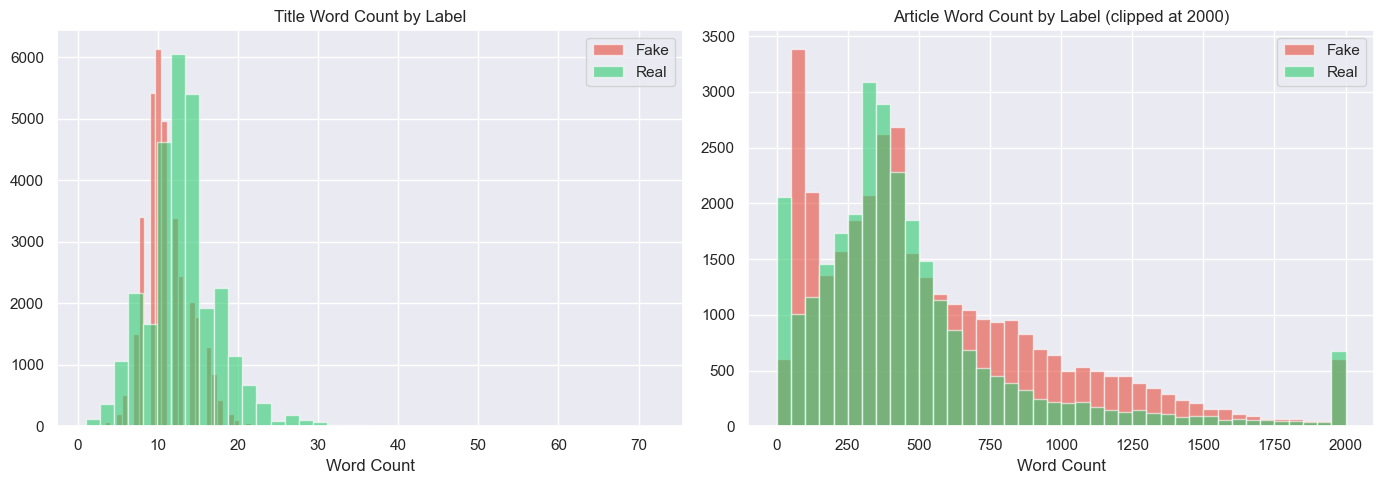

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip(['Fake', 'Real'], ['#e74c3c', '#2ecc71']):
    subset = df[df['label_name'] == label]
    axes[0].hist(subset['title_word_count'], bins=40, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['text_word_count'].clip(upper=2000), bins=40, alpha=0.6, label=label, color=color)

axes[0].set_title('Title Word Count by Label')
axes[0].set_xlabel('Word Count')
axes[0].legend()

axes[1].set_title('Article Word Count by Label (clipped at 2000)')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Punctuation & Capitalisation Features

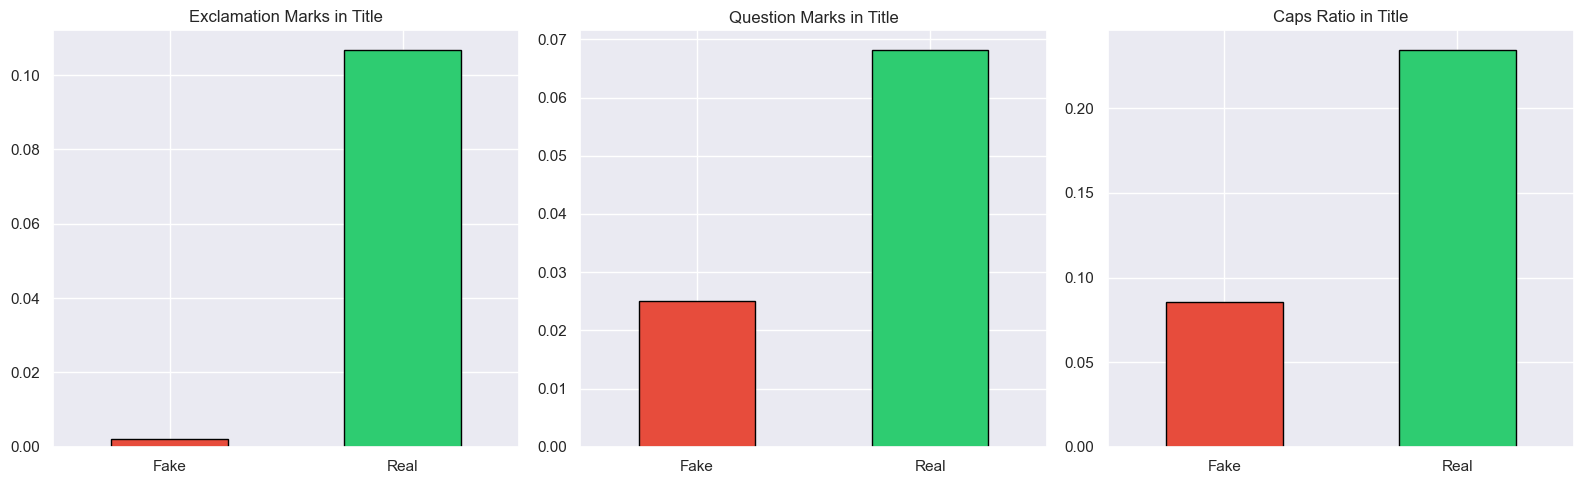

In [9]:
df['exclamation_count'] = df['title'].astype(str).apply(lambda x: x.count('!'))
df['question_count']    = df['title'].astype(str).apply(lambda x: x.count('?'))
df['caps_ratio']        = df['title'].astype(str).apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes,
    ['exclamation_count', 'question_count', 'caps_ratio'],
    ['Exclamation Marks in Title', 'Question Marks in Title', 'Caps Ratio in Title']):
    df.groupby('label_name')[col].mean().plot(kind='bar', ax=ax,
        color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 6. Most Common Words (Fake vs Real)

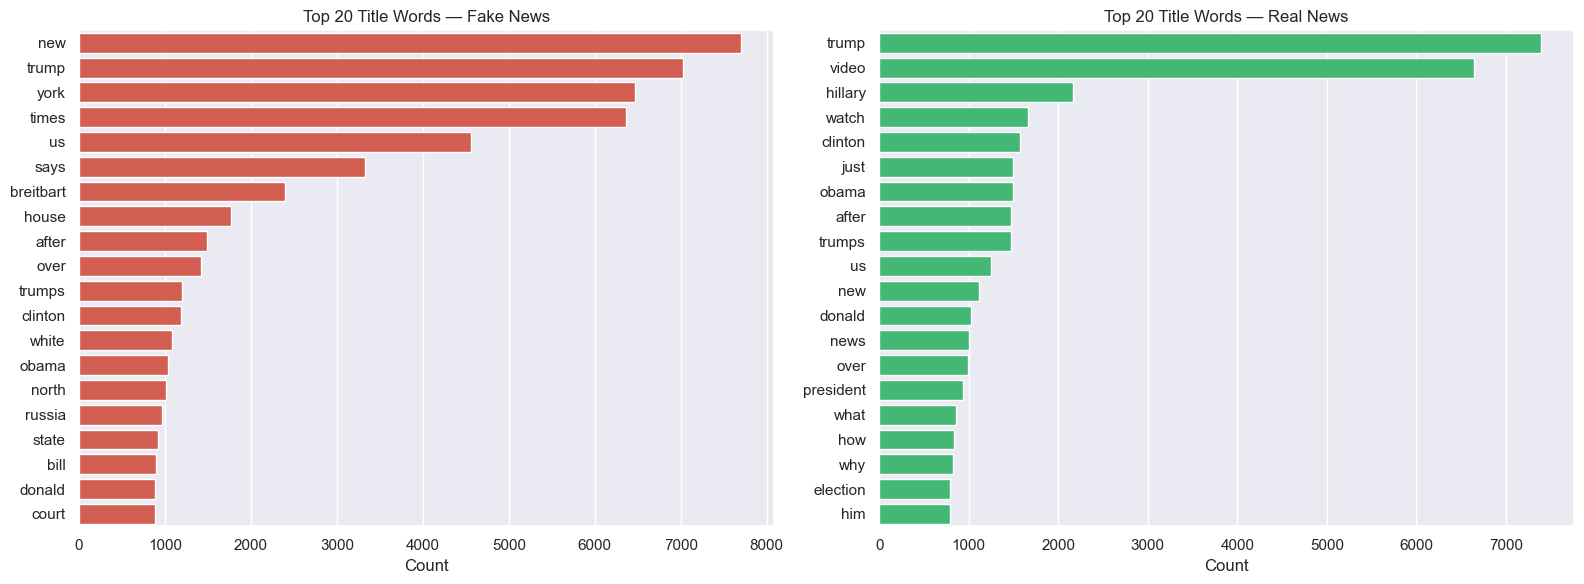

In [10]:
STOPWORDS = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','was','are','were','it','this','that','as','be','by','from','have',
    'has','had','he','she','they','we','i','you','said','will','its','not',
    'his','her','their','our','which','who','about','up','out','if','s',''
])

def top_words(series, n=20):
    words = ' '.join(series.astype(str).str.lower()).split()
    words = [re.sub(r'[^a-z]', '', w) for w in words]
    words = [w for w in words if w and w not in STOPWORDS]
    return Counter(words).most_common(n)

fake_words = top_words(df[df['label_name'] == 'Fake']['title'])
real_words = top_words(df[df['label_name'] == 'Real']['title'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, words, label, color in zip(
    axes,
    [fake_words, real_words],
    ['Fake', 'Real'],
    ['#e74c3c', '#2ecc71']
):
    words_df = pd.DataFrame(words, columns=['word', 'count'])
    sns.barplot(data=words_df, x='count', y='word', ax=ax, color=color)
    ax.set_title(f'Top 20 Title Words — {label} News')
    ax.set_xlabel('Count')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## 7. Summary Stats Table

In [11]:
summary = df.groupby('label_name').agg(
    count=('label', 'count'),
    avg_title_words=('title_word_count', 'mean'),
    avg_article_words=('text_word_count', 'mean'),
    avg_exclamations=('exclamation_count', 'mean'),
    avg_caps_ratio=('caps_ratio', 'mean')
).round(2)

print(summary)

            count  avg_title_words  avg_article_words  avg_exclamations  \
label_name                                                                
Fake        34791            11.05             578.25              0.00   
Real        28330            13.13             507.86              0.11   

            avg_caps_ratio  
label_name                  
Fake                  0.09  
Real                  0.23  


In [13]:
df.head(3)


,title,text,label,label_name,title_len,text_len,title_word_count,text_word_count,exclamation_count,question_count,caps_ratio
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,Real,130,5049,18,871,0,0,0.353846
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,Real,137,216,18,34,1,0,0.664234
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,Fake,105,8010,16,1321,0,0,0.038095
